# Project 2: Spotify Songs' Genre Segmentation

**Goal:** Explore Spotify's audio-feature dataset, understand what separates genres acoustically,
group songs into clusters based on their audio characteristics, and use those clusters to power a
simple content-based recommendation system.

**Workflow**
1. Data pre-processing
2. Exploratory Data Analysis (EDA) & visualizations
3. Correlation analysis
4. Clustering by audio features (unsupervised) and comparison to actual playlist genres
5. Supervised model (genre classifier) + feature importance
6. Recommendation system
7. Summary of insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 30)


## 1. Data Pre-processing

In [2]:
df = pd.read_csv("spotify_dataset.csv")
print("Shape:", df.shape)
df.head()


Shape: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [3]:
# Missing values check
df.isnull().sum()[df.isnull().sum() > 0]


track_name          5
track_artist        5
track_album_name    5
dtype: int64

In [4]:
# Only 5 rows are missing basic metadata (track/artist/album name) -> safe to drop
df = df.dropna(subset=["track_name", "track_artist", "track_album_name"]).reset_index(drop=True)
print("Shape after dropping incomplete metadata rows:", df.shape)

# The same track can appear in multiple playlists (duplicated track_id).
# Keep the full listing for EDA (playlist-level insights) but also build a
# de-duplicated, one-row-per-track table for clustering/modeling so popular
# tracks don't get over-weighted just for appearing in many playlists.
df_unique = df.drop_duplicates(subset=["track_id"]).reset_index(drop=True)
print("Unique tracks:", df_unique.shape[0], "  (full playlist listings:", df.shape[0], ")")


Shape after dropping incomplete metadata rows: (32828, 23)
Unique tracks: 28352   (full playlist listings: 32828 )


In [5]:
audio_features = ['danceability','energy','loudness','speechiness','acousticness',
                   'instrumentalness','liveness','valence','tempo']
df[audio_features].describe().T


,count,mean,std,min,25%,50%,75%,max
danceability,32828.0,0.654850,0.145092,0.000000,0.56300,0.672000,0.76100,0.983
energy,32828.0,0.698603,0.180916,0.000175,0.58100,0.721000,0.84000,1.000
loudness,32828.0,-6.719529,2.988641,-46.448000,-8.17125,-6.166000,-4.64500,1.275
speechiness,32828.0,0.107053,0.101307,0.000000,0.04100,0.062500,0.13200,0.918
acousticness,32828.0,0.175352,0.219644,0.000000,0.01510,0.080400,0.25500,0.994
instrumentalness,32828.0,0.084760,0.224245,0.000000,0.00000,0.000016,0.00483,0.994
liveness,32828.0,0.190175,0.154313,0.000000,0.09270,0.127000,0.24800,0.996
valence,32828.0,0.510556,0.233152,0.000000,0.33100,0.512000,0.69300,0.991
tempo,32828.0,120.883642,26.903632,0.000000,99.96100,121.984000,133.91825,239.440


## 2. Exploratory Data Analysis & Visualizations

We look at (a) how tracks are distributed across genres/subgenres, (b) how popularity behaves,
and (c) how the audio features themselves are distributed and differ by genre.

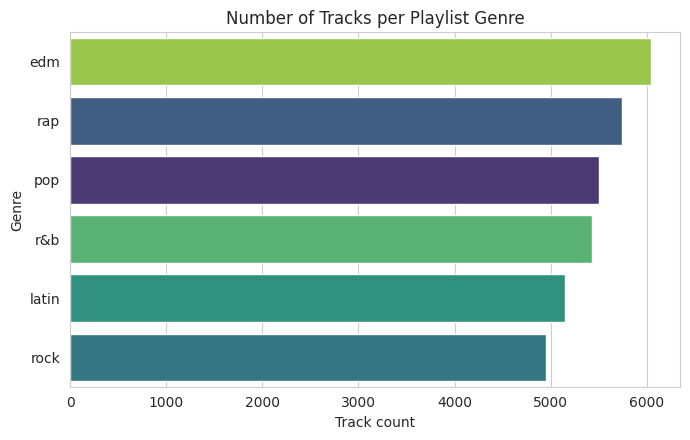

In [6]:
genre_order = df['playlist_genre'].value_counts().index
plt.figure(figsize=(7,4.5))
sns.countplot(data=df, y='playlist_genre', order=genre_order, hue='playlist_genre',
              palette='viridis', legend=False)
plt.title("Number of Tracks per Playlist Genre")
plt.xlabel("Track count"); plt.ylabel("Genre")
plt.tight_layout(); plt.show()


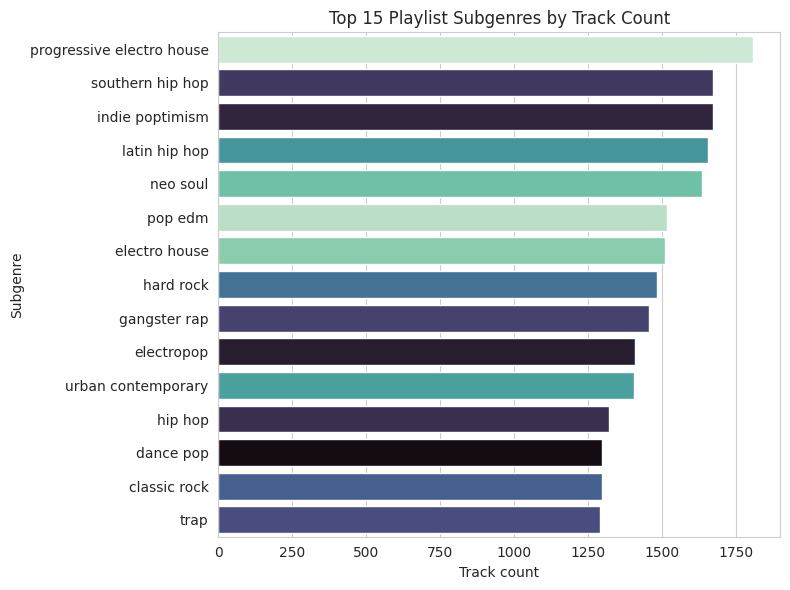

In [7]:
plt.figure(figsize=(8,6))
sub_order = df['playlist_subgenre'].value_counts().index[:15]
sns.countplot(data=df, y='playlist_subgenre', order=sub_order, hue='playlist_subgenre',
              palette='mako', legend=False)
plt.title("Top 15 Playlist Subgenres by Track Count")
plt.xlabel("Track count"); plt.ylabel("Subgenre")
plt.tight_layout(); plt.show()


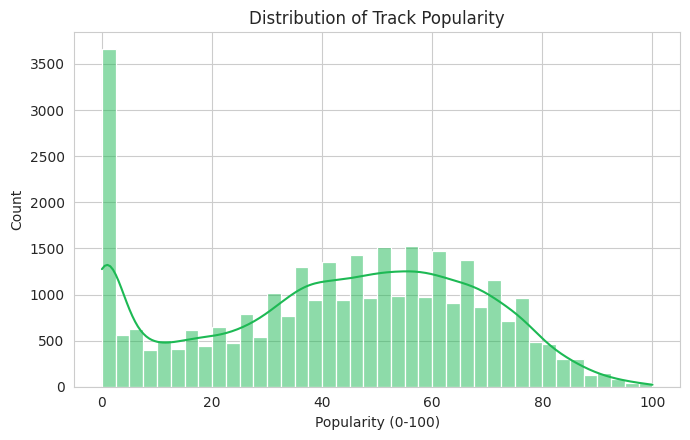

In [8]:
plt.figure(figsize=(7,4.5))
sns.histplot(df['track_popularity'], bins=40, kde=True, color='#1DB954')
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity (0-100)"); plt.ylabel("Count")
plt.tight_layout(); plt.show()


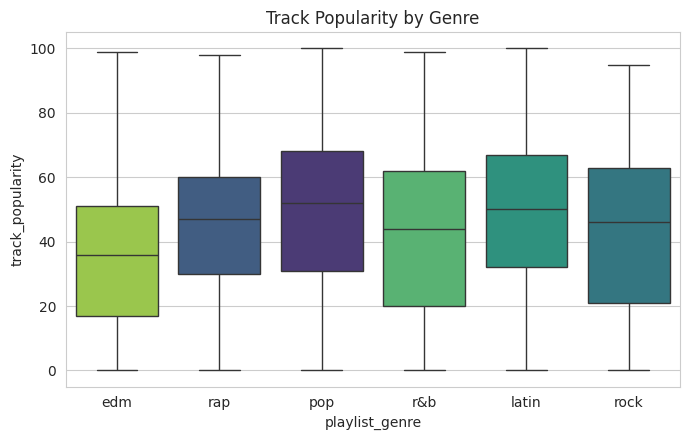

In [9]:
plt.figure(figsize=(7,4.5))
sns.boxplot(data=df, x='playlist_genre', y='track_popularity', order=genre_order,
            hue='playlist_genre', palette='viridis', legend=False)
plt.title("Track Popularity by Genre")
plt.tight_layout(); plt.show()


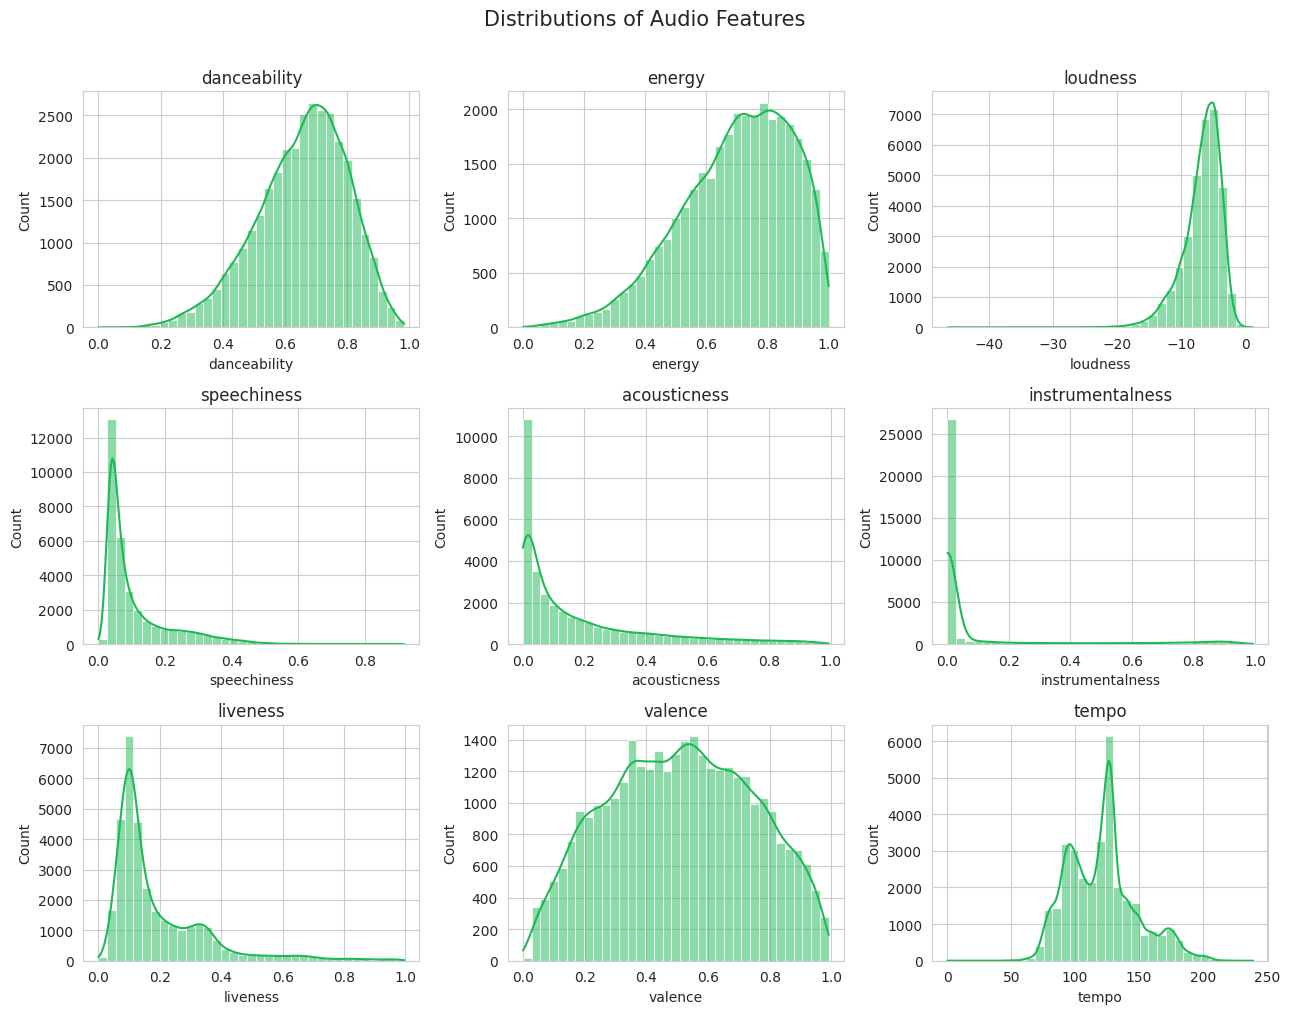

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(13,10))
for ax, feat in zip(axes.flat, audio_features):
    sns.histplot(df[feat], bins=35, kde=True, ax=ax, color='#1DB954')
    ax.set_title(feat)
plt.suptitle("Distributions of Audio Features", y=1.01, fontsize=15)
plt.tight_layout(); plt.show()


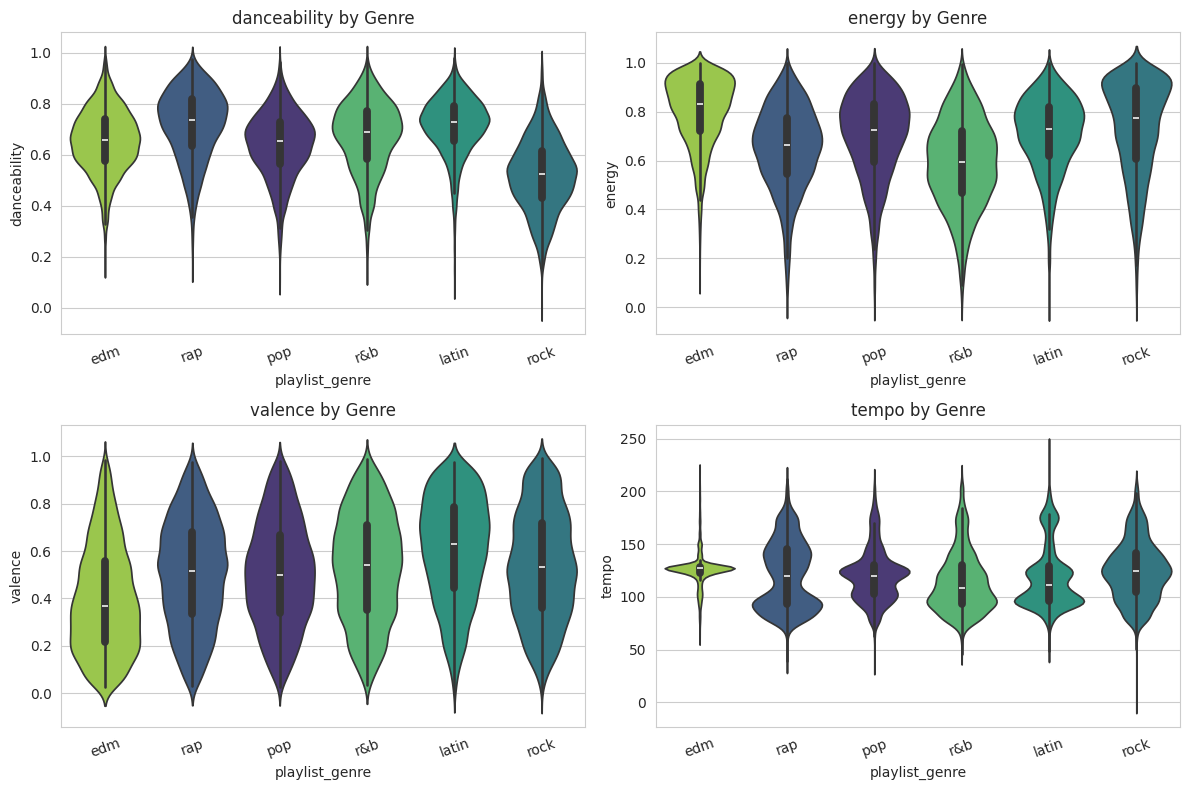

In [11]:
key_feats = ['danceability','energy','valence','tempo']
fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, feat in zip(axes.flat, key_feats):
    sns.violinplot(data=df, x='playlist_genre', y=feat, order=genre_order,
                    hue='playlist_genre', palette='viridis', legend=False, ax=ax)
    ax.set_title(f"{feat} by Genre")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


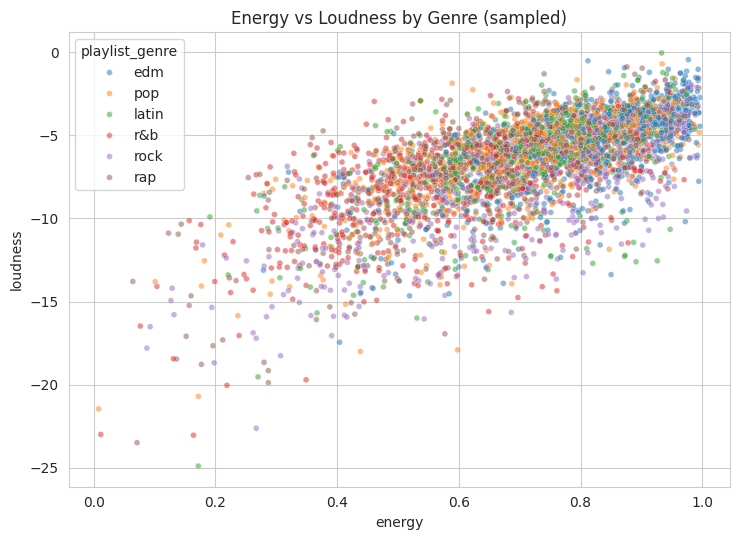

In [12]:
sample = df.sample(4000, random_state=42)
plt.figure(figsize=(7.5,5.5))
sns.scatterplot(data=sample, x='energy', y='loudness', hue='playlist_genre', alpha=0.5, s=18, palette='tab10')
plt.title("Energy vs Loudness by Genre (sampled)")
plt.tight_layout(); plt.show()


## 3. Correlation Matrix

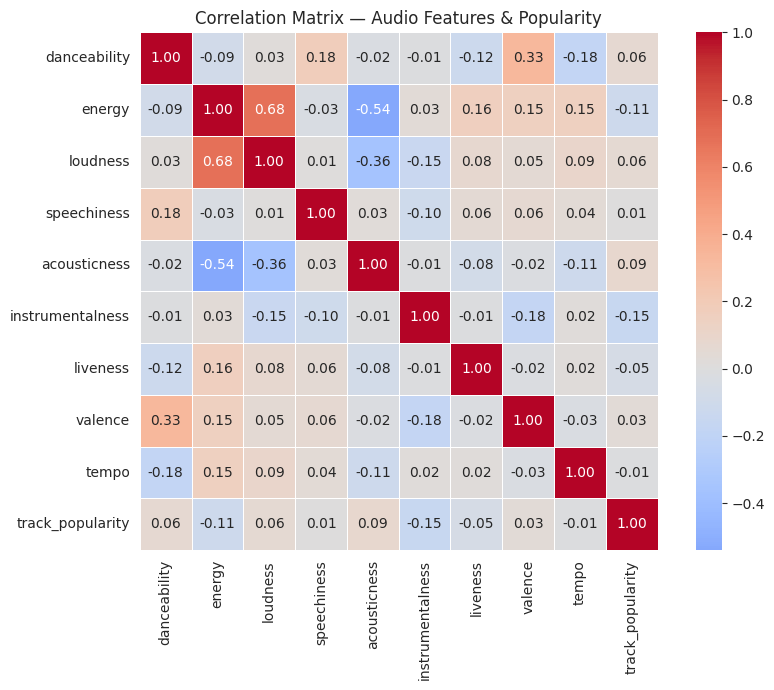

In [13]:
corr = df[audio_features + ['track_popularity']].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Audio Features & Popularity")
plt.tight_layout(); plt.show()


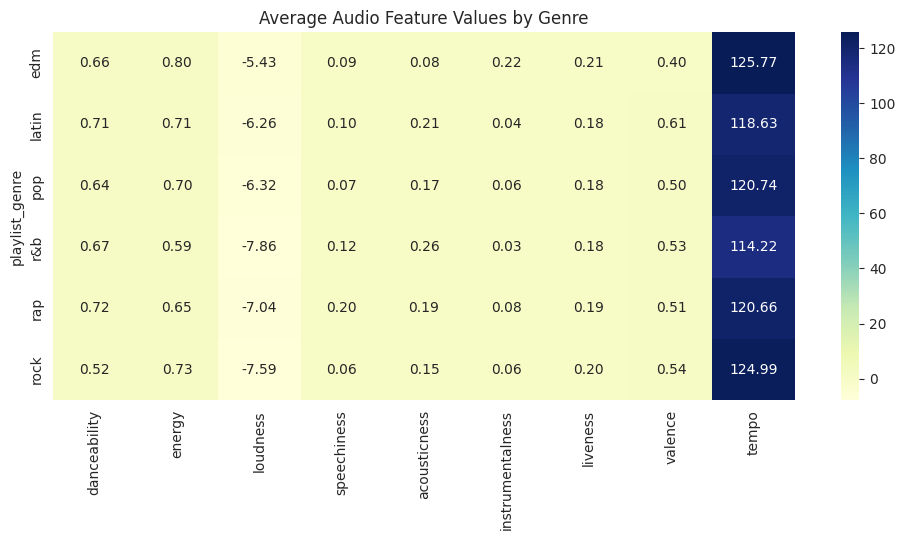

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
playlist_genre,,,,,,,,,
edm,0.655,0.802,-5.427,0.087,0.082,0.219,0.212,0.401,125.768
latin,0.713,0.708,-6.264,0.103,0.211,0.044,0.181,0.605,118.631
pop,0.639,0.701,-6.315,0.074,0.171,0.060,0.177,0.504,120.743
r&b,0.670,0.591,-7.865,0.117,0.260,0.029,0.175,0.531,114.222
rap,0.718,0.651,-7.043,0.197,0.193,0.076,0.192,0.505,120.661
rock,0.521,0.733,-7.589,0.058,0.145,0.062,0.203,0.537,124.989


In [14]:
genre_means = df.groupby('playlist_genre')[audio_features].mean()
plt.figure(figsize=(10,5.5))
sns.heatmap(genre_means, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("Average Audio Feature Values by Genre")
plt.tight_layout(); plt.show()
genre_means.round(3)


**Observations:**
- `energy` and `loudness` are strongly positively correlated (r ≈ 0.68) — louder tracks tend to sound more energetic, as expected.
- `energy` and `acousticness` are strongly negatively correlated (r ≈ -0.54) — acoustic tracks are quieter/lower-energy.
- `danceability` and `valence` are moderately positively correlated (r ≈ 0.33) — happier-sounding tracks tend to be more danceable.
- None of the audio features correlate strongly with `track_popularity` — popularity seems driven more by artist/marketing/cultural factors than by raw audio characteristics alone.
- Genre-wise, EDM stands out with high energy/low acousticness, rock has the lowest danceability, and latin/rap score highest on danceability.

## 4. Clustering by Audio Features

We scale the 9 audio features and run K-Means to see whether songs naturally group into clusters
that resemble the human-assigned playlist genres, or whether the acoustic structure cuts across genres differently.
Clustering is done on the **de-duplicated track table** so a song appearing in many playlists doesn't get extra weight.

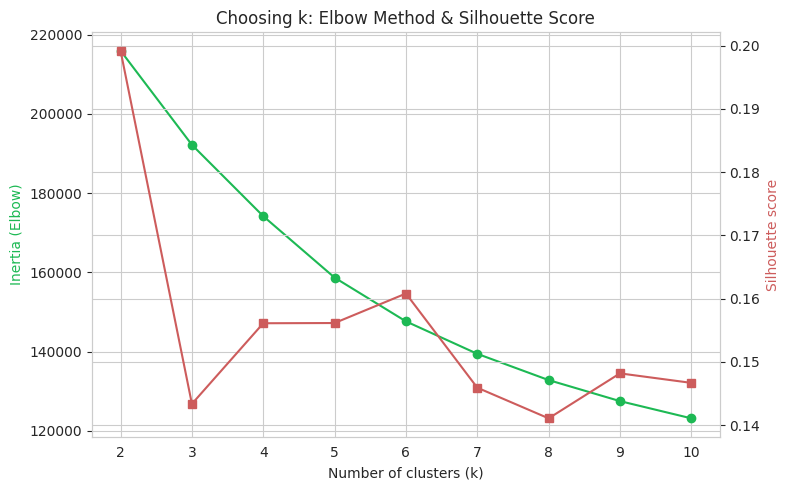

In [15]:
X = df_unique[audio_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, sils = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(list(K_range), inertias, marker='o', color='#1DB954')
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia (Elbow)", color='#1DB954')
ax2 = ax1.twinx()
ax2.plot(list(K_range), sils, marker='s', color='indianred')
ax2.set_ylabel("Silhouette score", color='indianred')
plt.title("Choosing k: Elbow Method & Silhouette Score")
plt.tight_layout(); plt.show()


The elbow flattens gradually with no sharp knee, and silhouette scores are low throughout
(≈0.14-0.20) — expected for audio features, since genres blend into each other acoustically rather
than forming tight, well-separated groups. We pick **k = 6** to match the number of playlist genres,
which makes the clusters directly interpretable and comparable to the ground-truth labels.

In [16]:
k_final = 6
km_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_unique = df_unique.copy()
df_unique['cluster'] = km_final.fit_predict(X_scaled)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df_unique['pca1'], df_unique['pca2'] = pcs[:,0], pcs[:,1]
print("Explained variance ratio (PC1, PC2):", pca.explained_variance_ratio_.round(3),
      " total:", round(pca.explained_variance_ratio_.sum(),3))


Explained variance ratio (PC1, PC2): [0.241 0.168]  total: 0.409


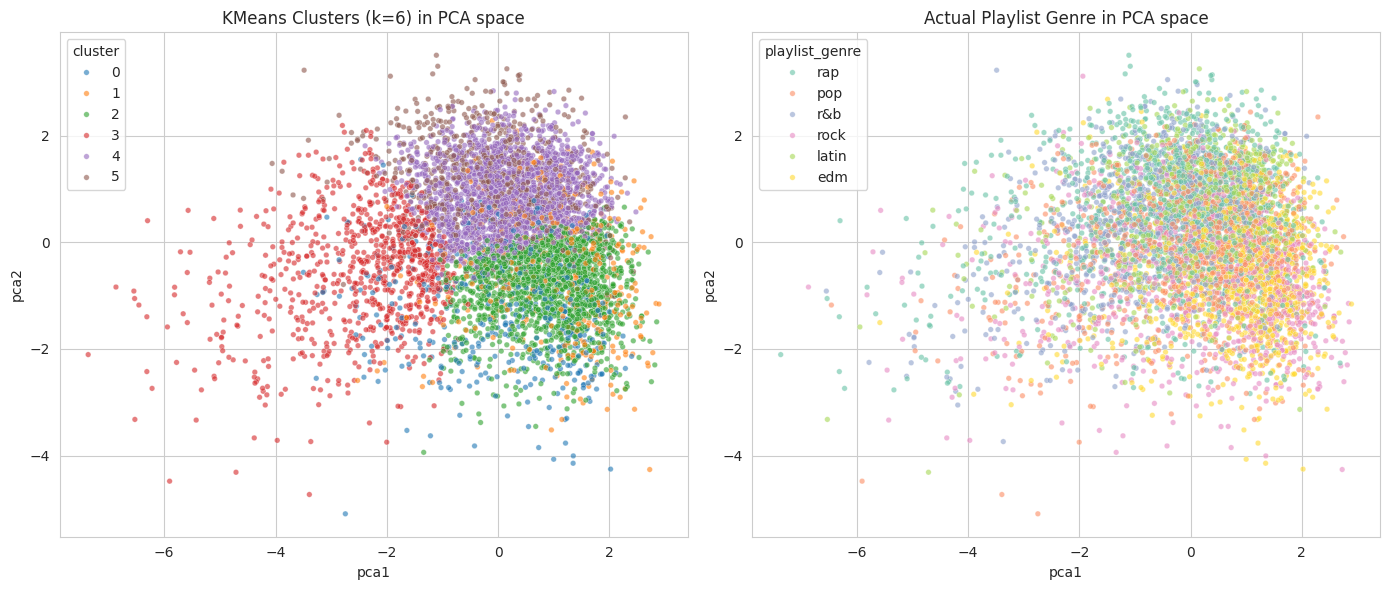

In [17]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
plot_sample = df_unique.sample(6000, random_state=1)
sns.scatterplot(data=plot_sample, x='pca1', y='pca2', hue='cluster', palette='tab10', alpha=0.6, s=16, ax=axes[0])
axes[0].set_title(f"KMeans Clusters (k={k_final}) in PCA space")
sns.scatterplot(data=plot_sample, x='pca1', y='pca2', hue='playlist_genre', palette='Set2', alpha=0.6, s=16, ax=axes[1])
axes[1].set_title("Actual Playlist Genre in PCA space")
plt.tight_layout(); plt.show()


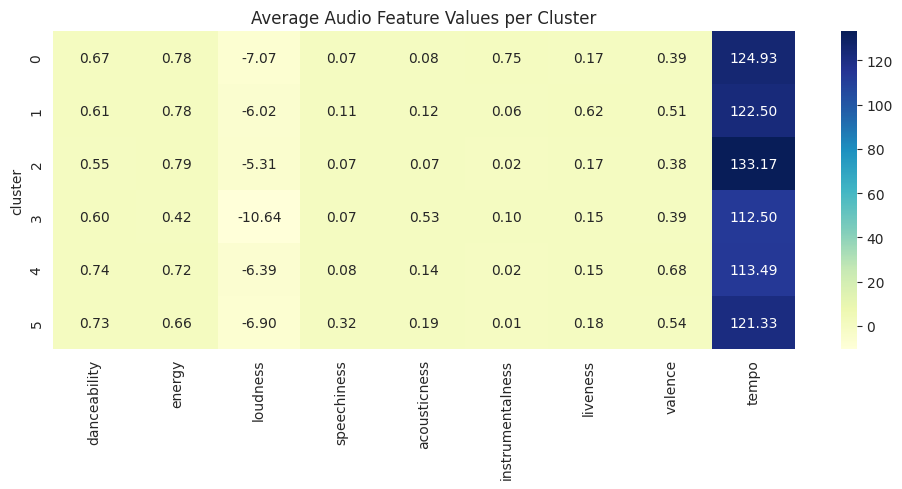

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
cluster,,,,,,,,,
0,0.665,0.778,-7.074,0.071,0.075,0.753,0.169,0.390,124.930
1,0.608,0.784,-6.020,0.110,0.115,0.061,0.620,0.508,122.502
2,0.545,0.794,-5.314,0.073,0.067,0.023,0.173,0.382,133.174
3,0.602,0.420,-10.637,0.072,0.530,0.101,0.147,0.391,112.502
4,0.739,0.723,-6.390,0.075,0.143,0.016,0.148,0.683,113.487
5,0.726,0.664,-6.900,0.316,0.187,0.011,0.178,0.544,121.327


In [18]:
cluster_profile = df_unique.groupby('cluster')[audio_features].mean()
plt.figure(figsize=(10,5))
sns.heatmap(cluster_profile, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("Average Audio Feature Values per Cluster")
plt.tight_layout(); plt.show()
cluster_profile.round(3)


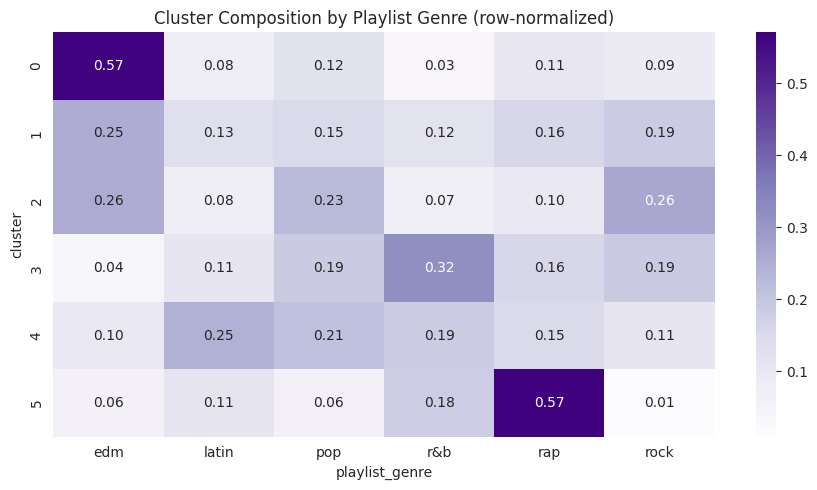

In [19]:
ct = pd.crosstab(df_unique['cluster'], df_unique['playlist_genre'], normalize='index')
plt.figure(figsize=(9,5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap='Purples')
plt.title("Cluster Composition by Playlist Genre (row-normalized)")
plt.tight_layout(); plt.show()


**Observations:**
- The two PCA components capture only ~41% of the total variance, so a 2-D picture is a simplified view — clusters that look like they overlap may still be somewhat separated in the full 9-D feature space.
- Some clusters map fairly cleanly onto genres (e.g. a low-energy/high-acousticness cluster is dominated by r&b/pop; a high-energy/low-acousticness cluster is dominated by edm/rock), while others are a genuine mix of several genres.
- This confirms that playlist genre is a mix of acoustic *and* cultural/contextual signal — audio features alone explain part, but not all, of how humans categorize genre.

## 5. Predictive Model: Can Audio Features Predict Genre?

As a complementary, supervised view, we train a Random Forest to predict `playlist_genre` directly
from the audio features, and inspect which features matter most.

In [20]:
X_full = df[audio_features]
y_full = df['playlist_genre']

X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
scaler2 = StandardScaler()
X_train_s = scaler2.fit_transform(X_train)
X_test_s = scaler2.transform(X_test)

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train_s, y_train)
pred = clf.predict(X_test_s)

acc = accuracy_score(y_test, pred)
print(f"Test accuracy: {acc:.3f}  (vs. {1/6:.3f} random-guess baseline for 6 classes)")
print(classification_report(y_test, pred))


Test accuracy: 0.541  (vs. 0.167 random-guess baseline for 6 classes)
              precision    recall  f1-score   support

         edm       0.65      0.65      0.65      1209
       latin       0.51      0.42      0.46      1031
         pop       0.37      0.33      0.35      1101
         r&b       0.45      0.45      0.45      1086
         rap       0.56      0.64      0.60      1149
        rock       0.67      0.75      0.71       990

    accuracy                           0.54      6566
   macro avg       0.53      0.54      0.54      6566
weighted avg       0.53      0.54      0.54      6566



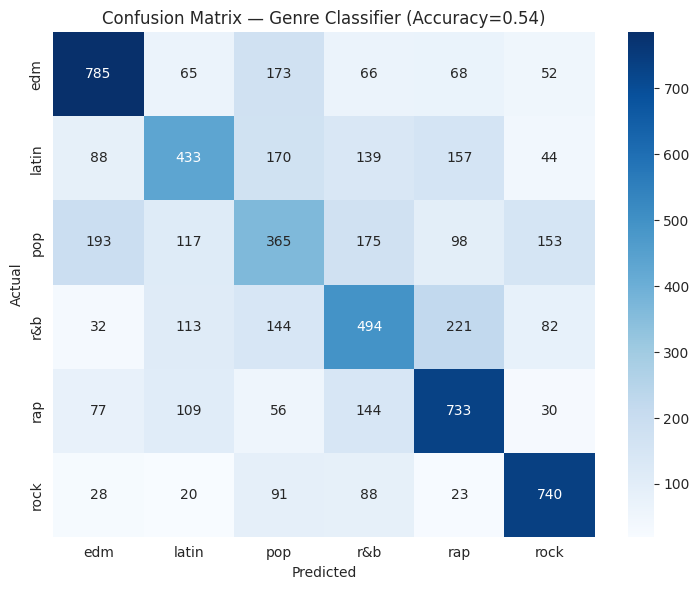

In [21]:
cm = confusion_matrix(y_test, pred, labels=clf.classes_)
plt.figure(figsize=(7.5,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title(f"Confusion Matrix — Genre Classifier (Accuracy={acc:.2f})")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


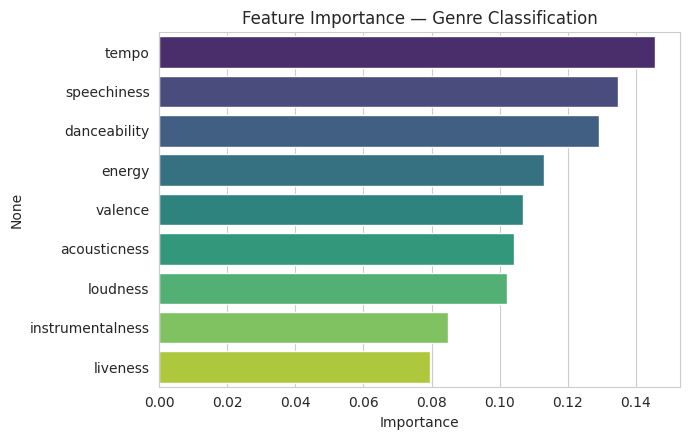

tempo               0.145740
speechiness         0.134690
danceability        0.129166
energy              0.112958
valence             0.106811
acousticness        0.104179
loudness            0.102251
instrumentalness    0.084782
liveness            0.079423
dtype: float64

In [22]:
importances = pd.Series(clf.feature_importances_, index=audio_features).sort_values(ascending=False)
plt.figure(figsize=(7,4.5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis', legend=False)
plt.title("Feature Importance — Genre Classification")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()
importances


**Observations:** the model reaches roughly **54% accuracy** on 6 balanced classes, more than 3x
the 16.7% random baseline — audio features carry a real signal about genre, but far from a perfect one.
EDM and rock are the easiest to separate (high recall); pop and r&b are the hardest, since they
acoustically overlap with several other genres. `tempo`, `speechiness` and `danceability` are the most
informative features.

## 6. Recommendation System

Using the cluster assignments as a first coarse filter ("same sound neighborhood") and cosine
similarity of the scaled audio-feature vectors for fine-grained ranking, we build a simple
content-based recommender: give it a track, get back the most sonically similar tracks.

In [23]:
feat_matrix = StandardScaler().fit_transform(df_unique[audio_features])

def recommend_tracks(track_name, artist=None, n=5):
    matches = df_unique[df_unique['track_name'].str.lower() == track_name.lower()]
    if artist:
        matches = matches[matches['track_artist'].str.lower() == artist.lower()]
    if matches.empty:
        return f"Track '{track_name}' not found."
    seed_idx = matches.index[0]
    seed_cluster = df_unique.loc[seed_idx, 'cluster']

    candidates = df_unique[(df_unique['cluster'] == seed_cluster) & (df_unique.index != seed_idx)]
    sims = cosine_similarity(feat_matrix[seed_idx].reshape(1,-1), feat_matrix[candidates.index])[0]
    candidates = candidates.copy()
    candidates['similarity'] = sims
    return candidates.sort_values('similarity', ascending=False).head(n)[
        ['track_name','track_artist','playlist_genre','playlist_subgenre','similarity']]

seed = df_unique[df_unique['playlist_genre']=='rock'].iloc[5]
print(f"Seed track: {seed['track_name']} — {seed['track_artist']}  (genre: {seed['playlist_genre']})")
recommend_tracks(seed['track_name'], seed['track_artist'])


Seed track: Mr. Brownstone — Guns N' Roses  (genre: rock)


,track_name,track_artist,playlist_genre,playlist_subgenre,similarity
13709,Light in Life,Silvera,rock,hard rock,0.964929
13124,Self Esteem,The Offspring,rock,permanent wave,0.916346
1836,Immigrant Song - Remaster,Led Zeppelin,pop,post-teen pop,0.902518
13681,Beyond The Wave,Of Allies,rock,hard rock,0.895089
13835,Gypsy Road,Cinderella,rock,hard rock,0.891455


In [24]:
seed2 = df_unique[df_unique['playlist_genre']=='edm'].iloc[10]
print(f"Seed track: {seed2['track_name']} — {seed2['track_artist']}  (genre: {seed2['playlist_genre']})")
recommend_tracks(seed2['track_name'], seed2['track_artist'])


Seed track: My Shit Bang — Awnix & Toobaï  (genre: edm)


,track_name,track_artist,playlist_genre,playlist_subgenre,similarity
20853,Mammon's Mantra,Deca,r&b,hip pop,0.974876
24559,Bottle In The Mix,Dozer,edm,electro house,0.963457
2464,Guilty,Neon Dreams,pop,electropop,0.947989
23659,Walking On Water,Albin Myers,edm,electro house,0.943662
21537,Get It Shawty - Main,Lloyd,r&b,new jack swing,0.931166


## 7. Summary of Insights

1. **Genre balance:** the dataset is fairly balanced across 6 genres (edm, rap, pop, r&b, latin, rock), each with 4,900-6,000 tracks, spread across 24 subgenres.
2. **Popularity is independent of raw audio features** — no audio feature correlates strongly with `track_popularity`, suggesting popularity is driven mainly by external factors (artist fame, marketing, playlist placement) rather than the sound of the track itself.
3. **Feature relationships:** energy↔loudness (+), energy↔acousticness (−), and danceability↔valence (+) are the clearest relationships in the data.
4. **Clustering:** unsupervised K-Means (k=6) recovers a *partial* genre structure — some clusters map cleanly to a dominant genre (e.g. high-energy/low-acoustic → edm/rock), but others mix several genres, showing that "genre" is not purely acoustic.
5. **Predictive power:** a Random Forest classifier reaches ~54% accuracy (vs 16.7% random) predicting genre from audio features alone — real signal, but genres like pop/r&b are acoustically close and hard to separate.
6. **Recommendation system:** combining cluster membership (coarse filter) with cosine similarity on audio features (fine ranking) produces sensible, sonically-coherent recommendations, and this is a lightweight, explainable foundation for a content-based recommender that could be extended with collaborative-filtering signals (skips, saves, co-occurrence in playlists) for a production system.
